<p align="center">
  <img src="../assets/prodinno_logo.png" alt="Prodinno" width="200">
</p>

<h4 align="center">Session 1 · Linear & Logistic Regression</h4>
<h1 align="center">Logistic Regression — Breast Cancer Diagnosis</h1>
<p align="center"><i>Notebook 0 — Understanding the dataset and learning to detect (and fix) class imbalance</i></p>

---

## 1. The Dataset: Breast Cancer Wisconsin (Diagnostic)

This dataset comes from **digitized images of a fine-needle aspirate (FNA) biopsy** of a
breast mass. For each of the 569 patients in the study, a clinician examined an image of the
cell nuclei present in the sample and computed **10 base measurements** describing the shape
and texture of those nuclei. Because a single image contains many nuclei, each base
measurement is summarized three ways across all nuclei in the image:

- **`_mean`** — the average value of the measurement across all nuclei in the image.
- **`_se`** — the standard error of the measurement (how much the nuclei disagree with one
  another / how noisy the measurement is).
- **`_worst`** — the mean of the three largest (most extreme) values observed, i.e. a proxy
  for the single most abnormal nucleus in the sample.

$$10 \text{ base measurements} \times 3 \text{ summary statistics} = 30 \text{ features}$$

The **10 base measurements** and what they physically capture:

| Feature | What it measures |
|---|---|
| `radius` | mean distance from the nucleus center to its perimeter |
| `texture` | standard deviation of grayscale intensity values (surface roughness) |
| `perimeter` | length of the nucleus boundary |
| `area` | area enclosed by the nucleus boundary |
| `smoothness` | local variation in radius length (how jagged the edge is at a fine scale) |
| `compactness` | $\text{perimeter}^2 / \text{area} - 1$, penalizes irregular, non-circular shapes |
| `concavity` | severity of concave (inward-bulging) portions of the boundary |
| `concave points` | number of concave portions of the boundary |
| `symmetry` | how symmetric the nucleus shape is about its main axis |
| `fractal dimension` | a "coastline approximation" measure of boundary complexity |

**Target:** `diagnosis` — `malignant` (cancerous) or `benign` (non-cancerous).

> **Clinical intuition.** Malignant (cancerous) cells tend to divide chaotically and lose the
> orderly structure of healthy tissue. This tends to show up as **larger, more irregularly
> shaped, and more concave nuclei** — i.e. higher `radius`, `perimeter`, `area`, `concavity`
> and `concave points`, and lower `smoothness`/`symmetry`. This is exactly the kind of prior
> knowledge that will let us sanity-check the exploratory data analysis in the next notebook:
> we *expect* these features to separate the two classes reasonably well.

In [1]:
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

RANDOM_STATE = 97

raw = pd.read_csv("data/breast_cancer_raw.csv")
print(raw.shape)
raw.head(3)

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant


In [2]:
# The raw column names are "mean radius", "radius error", "worst radius", ...
# Rename to the tidy snake_case convention used throughout the workshop:
#   <feature>_mean, <feature>_se, <feature>_worst

def tidy_name(col):
    if col == "diagnosis":
        return col
    if col.startswith("mean "):
        return col[len("mean "):].replace(" ", "_") + "_mean"
    if col.startswith("worst "):
        return col[len("worst "):].replace(" ", "_") + "_worst"
    if col.endswith(" error"):
        return col[: -len(" error")].replace(" ", "_") + "_se"
    raise ValueError(f"Unexpected column name: {col}")

df = raw.rename(columns=tidy_name)
feature_cols = [c for c in df.columns if c != "diagnosis"]
df = df[feature_cols + ["diagnosis"]]
df.head(3)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave_points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            569 non-null

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


**Reading the `.describe()` table:**

- Scales vary enormously across features — `area_mean` ranges into the thousands while
  `smoothness_mean` lives in the 0.05–0.16 range. This is expected (area grows with the
  *square* of radius) and is exactly why **feature scaling** will matter once we train a
  model in Notebook 2.
- No missing values (`.info()` shows 569 non-null entries for all 31 columns) — a clean
  starting point.
- The class split is `benign: 357`, `malignant: 212` (~63% / 37%). This is a *mild* real-world
  imbalance, not a severe one. To make the dangers of imbalance concrete for teaching
  purposes, we will now deliberately manufacture a much more **severe** imbalance.

## 2. Injecting Severe Class Imbalance

Many real diagnostic settings are far more imbalanced than 63/37 — a rare disease might
appear in well under 10% of screened patients. To give ourselves a concrete, hands-on example
of *why* imbalance is dangerous and *how* to detect and fix it, we will build a synthetic
"dirty" version of this dataset:

- Keep **all 357 benign rows** untouched.
- Keep only a **random ~30-row sample of the 212 malignant rows** (about 8% of the resulting
  data).

This is a **teaching artifact** — a controlled demonstration, not a real clinical scenario.
The rest of this notebook uses `breast_cancer_dirty.csv` purely to illustrate detection and
correction techniques.

In [5]:
rng = np.random.RandomState(RANDOM_STATE)

benign = df[df["diagnosis"] == "benign"]
malignant = df[df["diagnosis"] == "malignant"]

# Keep ~8% malignant: 357 benign rows -> want malignant ~= 357 * 0.08 / 0.92 ~= 31
n_malignant_keep = int(round(len(benign) * 0.08 / 0.92))
malignant_sample = malignant.sample(n=n_malignant_keep, random_state=RANDOM_STATE)

dirty = pd.concat([benign, malignant_sample], axis=0).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(dirty["diagnosis"].value_counts())
print(f"Malignant share: {dirty['diagnosis'].eq('malignant').mean():.1%}")

dirty.to_csv("data/breast_cancer_dirty.csv", index=False)

diagnosis
benign       357
malignant     31
Name: count, dtype: int64
Malignant share: 8.0%


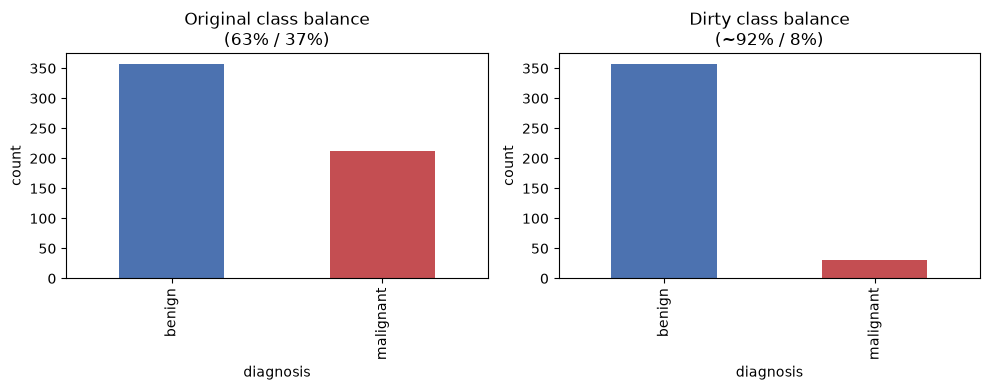

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df["diagnosis"].value_counts().reindex(["benign", "malignant"]).plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"]
)
axes[0].set_title("Original class balance\n(63% / 37%)")
axes[0].set_ylabel("count")

dirty["diagnosis"].value_counts().reindex(["benign", "malignant"]).plot(
    kind="bar", ax=axes[1], color=["#4C72B0", "#C44E52"]
)
axes[1].set_title("Dirty class balance\n(~92% / 8%)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

A bar chart like this is the fastest way to **detect** class imbalance — if one bar
dwarfs the other, every downstream metric needs to be interpreted with suspicion.

## 3. The Accuracy Trap

Why is severe imbalance dangerous? Because **accuracy stops being a meaningful metric.** A
model that never even looks at the data and simply predicts the majority class every time
will score deceptively well.

$$\text{accuracy} = \frac{\text{correct predictions}}{\text{total predictions}}$$

If 92% of rows are benign, a classifier that *always* says "benign" is right 92% of the time
— while being completely clinically useless, since it never once catches a malignant case
(its recall on malignant is exactly 0).

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = dirty.drop(columns=["diagnosis"])
y = dirty["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print(f"Dummy 'always benign' accuracy: {accuracy_score(y_test, y_pred_dummy):.1%}")
print()
print(classification_report(y_test, y_pred_dummy, zero_division=0))

Dummy 'always benign' accuracy: 92.3%

              precision    recall  f1-score   support

      benign       0.92      1.00      0.96       108
   malignant       0.00      0.00      0.00         9

    accuracy                           0.92       117
   macro avg       0.46      0.50      0.48       117
weighted avg       0.85      0.92      0.89       117



> **The trap.** >90% accuracy, yet **recall for `malignant` is 0.00** — the model
> catches zero cancer cases. In a screening context this is the worst possible failure mode:
> confident-looking accuracy hiding total blindness to the class that matters most. This is
> exactly why, under imbalance, we must look past accuracy to **recall, precision, F1, and
> confusion matrices per class** (Notebook 3 covers these formulas in depth).

## 4. Fixing Imbalance — Two Non-Destructive Techniques

We want techniques that **do not throw away any real, observed data**. Two standard options:

### 4.1 `class_weight="balanced"`

Most scikit-learn classifiers accept a `class_weight` parameter. Setting it to `"balanced"`
re-weights the loss function so that mistakes on the minority class cost proportionally more,
inversely proportional to class frequency:

$$w_c = \frac{n_{\text{samples}}}{n_{\text{classes}} \times n_c}$$

where $n_c$ is the number of samples in class $c$. This changes **how much each row counts
during training** — it touches **zero rows** of the actual data.

### 4.2 SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE generates new **synthetic** minority-class rows by interpolating between a real
minority sample $x_i$ and one of its $k$ nearest minority-class neighbors $x_{zi}$:

$$x_{\text{new}} = x_i + \lambda \cdot (x_{zi} - x_i), \qquad \lambda \sim \mathcal{U}(0, 1)$$

This manufactures plausible new minority examples that sit *between* existing real ones,
rather than simply duplicating rows. Every real row is kept; new rows are added only for the
minority class.

> **Critical rule: SMOTE must only ever be applied to the training split, never to the test
> set.** SMOTE builds its synthetic points by looking at nearest neighbors *within the data
> it is given*. If SMOTE were applied before splitting (or applied directly to the test set),
> synthetic test points could be interpolated from real training points' neighbors — meaning
> information about the test set would leak backwards into training, or the test set itself
> would contain fabricated (not real, observed) cases. Either way, the resulting evaluation
> metrics would be **optimistically biased and would not reflect real-world performance**,
> because we would be partially evaluating the model on data manufactured from data it
> already learned from. The test set must always stay 100% real, untouched, and
> representative of the deployment distribution.

### 4.3 What to avoid: naive random undersampling

The tempting "quick fix" is to randomly delete majority-class rows until the classes balance.
This *works* in the narrow sense that the resulting classes are balanced, but it is
**destructive**: it throws away real, valid, hard-won observations.

In [8]:
# Demonstrating why naive random undersampling is costly: it discards real data.
n_malignant_dirty = (y_train == "malignant").sum()
majority_undersampled = X_train[y_train == "benign"].sample(n=n_malignant_dirty, random_state=RANDOM_STATE)
n_discarded = (y_train == "benign").sum() - n_malignant_dirty

print(f"Benign rows in training split BEFORE undersampling: {(y_train == 'benign').sum()}")
print(f"Benign rows in training split AFTER undersampling:  {len(majority_undersampled)}")
print(f"Real, valid observations permanently discarded:     {n_discarded}")
print(f"Total training rows shrinks from {len(X_train)} to only {2 * n_malignant_dirty}.")

Benign rows in training split BEFORE undersampling: 249
Benign rows in training split AFTER undersampling:  22
Real, valid observations permanently discarded:     227
Total training rows shrinks from 271 to only 44.


> The printed counts above show undersampling would throw away the vast majority of real
> benign patients' worth of data just to force balance, leaving a tiny, high-variance
> training set. Compare this to `class_weight="balanced"` (discards 0 rows) and SMOTE
> (discards 0 real rows, and only adds synthetic minority rows to *training*). **Naive random
> undersampling of the majority class is the approach to avoid** whenever the minority class
> is small — it is the one strategy here that destroys information.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_bin = (y_train == "malignant").astype(int)
y_test_bin = (y_test == "malignant").astype(int)

# --- Fix 1: class_weight="balanced", trained on the untouched imbalanced training data
model_weighted = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE)
model_weighted.fit(X_train_scaled, y_train_bin)
y_pred_weighted = model_weighted.predict(X_test_scaled)

print("=== class_weight='balanced' ===")
print(classification_report(y_test_bin, y_pred_weighted, target_names=["benign", "malignant"], zero_division=0))

=== class_weight='balanced' ===


              precision    recall  f1-score   support

      benign       1.00      0.99      1.00       108
   malignant       0.90      1.00      0.95         9

    accuracy                           0.99       117
   macro avg       0.95      1.00      0.97       117
weighted avg       0.99      0.99      0.99       117



In [10]:
from imblearn.over_sampling import SMOTE

# --- Fix 2: SMOTE, applied ONLY to the training split
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_bin)

print("Training class balance BEFORE SMOTE:")
print(pd.Series(y_train_bin).value_counts().rename({0: "benign", 1: "malignant"}))
print("\nTraining class balance AFTER SMOTE:")
print(pd.Series(y_train_smote).value_counts().rename({0: "benign", 1: "malignant"}))

model_smote = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test_scaled)  # test set is UNTOUCHED, still natural imbalance

print("\n=== SMOTE-balanced training ===")
print(classification_report(y_test_bin, y_pred_smote, target_names=["benign", "malignant"], zero_division=0))

Training class balance BEFORE SMOTE:
diagnosis
benign       249
malignant     22
Name: count, dtype: int64

Training class balance AFTER SMOTE:
diagnosis
benign       249
malignant    249
Name: count, dtype: int64

=== SMOTE-balanced training ===
              precision    recall  f1-score   support

      benign       1.00      0.99      1.00       108
   malignant       0.90      1.00      0.95         9

    accuracy                           0.99       117
   macro avg       0.95      1.00      0.97       117
weighted avg       0.99      0.99      0.99       117



In [11]:
# For comparison: a model with NO fix at all, trained on the untouched imbalanced data
model_naive = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
model_naive.fit(X_train_scaled, y_train_bin)
y_pred_naive = model_naive.predict(X_test_scaled)

print("=== No fix (naive) ===")
print(classification_report(y_test_bin, y_pred_naive, target_names=["benign", "malignant"], zero_division=0))

=== No fix (naive) ===
              precision    recall  f1-score   support

      benign       0.98      1.00      0.99       108
   malignant       1.00      0.78      0.88         9

    accuracy                           0.98       117
   macro avg       0.99      0.89      0.93       117
weighted avg       0.98      0.98      0.98       117



## 5. Before / After Comparison

Class distribution, and confusion matrices for the model trained **with** a fix vs.
**without** a fix, at the default classification threshold of 0.5.

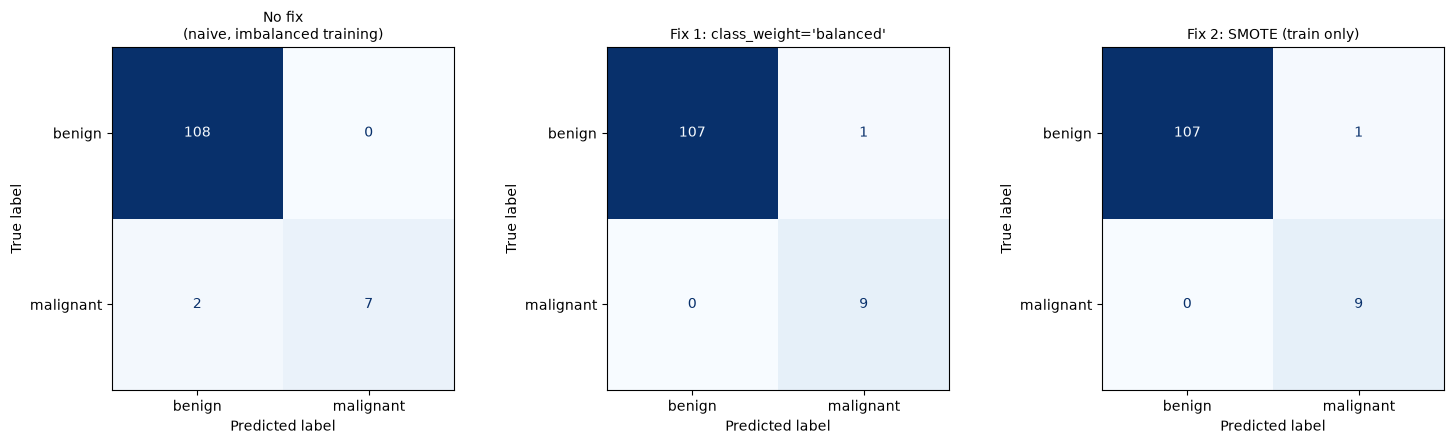

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, preds, title in zip(
    axes,
    [y_pred_naive, y_pred_weighted, y_pred_smote],
    ["No fix\n(naive, imbalanced training)", "Fix 1: class_weight='balanced'", "Fix 2: SMOTE (train only)"],
):
    cm = confusion_matrix(y_test_bin, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["benign", "malignant"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.show()

**Reading the three confusion matrices:** the *no-fix* model, trained on ~92%/8%
imbalanced data, tends to miss a much larger fraction of the (rare) malignant cases in the
bottom-left cell (false negatives) than either fixed model. Both `class_weight="balanced"`
and SMOTE push the model to pay attention to the minority class, typically catching more true
malignant cases (fewer false negatives) at some cost in extra false positives on benign
cases — a trade-off that is usually far preferable in a diagnostic setting, where missing a
cancer case is much more costly than a false alarm.

| Fix | Rows discarded | Rows fabricated | Touches test set? |
|---|---|---|---|
| Naive random undersampling | many (majority class) | 0 | no |
| `class_weight="balanced"` | 0 | 0 | no |
| SMOTE | 0 | some (minority class, train only) | **never** |

Both `class_weight="balanced"` and SMOTE are non-destructive: no real observation is ever
deleted. Naive undersampling is the one technique above that destroys real data, which is
why it is the approach to avoid.

## 6. Saving the Clean Dataset

Unlike `breast_cancer_dirty.csv` (which we built by throwing away ~85% of the malignant
rows purely to *demonstrate* the danger of imbalance), `breast_cancer_clean.csv` keeps
**every one of the original 569 real rows** — nothing is undersampled here.

Why isn't there anything else to "fix" row-wise? Because the *correct* place to apply an
imbalance fix is **at train time, on the training split only** — exactly as demonstrated
above with `class_weight="balanced"` and train-only SMOTE. Baking a fix into the saved CSV
itself would either destroy real rows (undersampling) or contaminate the eventual test split
with synthetic rows (if SMOTE were applied before splitting). So the "clean" dataset is
simply the full, untouched, tidied data — the imbalance fix itself is deferred to Notebook 2
(train/test split) and Notebook 3 (model training), where it can be applied correctly, only
to the training partition.

In [13]:
clean = df.copy()
clean.to_csv("data/breast_cancer_clean.csv", index=False)
print(clean.shape)
clean["diagnosis"].value_counts()

(569, 31)


diagnosis
benign       357
malignant    212
Name: count, dtype: int64

## Summary

- **Detected** imbalance visually (class-count bar chart) and diagnosed the **accuracy
  trap** with a dummy classifier that scores >90% accuracy while being clinically useless.
- **Fixed** imbalance two non-destructive ways: `class_weight="balanced"` (re-weights the
  loss, touches 0 rows) and **SMOTE** (adds synthetic minority rows, train split only, never
  the test set).
- **Avoided** naive random undersampling of the majority class, which discards real, valid
  observations.
- Saved `breast_cancer_clean.csv` — the full 569-row dataset — for use in the next
  notebooks. The imbalance fix itself is deferred to train time on the training split only.